<a href="https://colab.research.google.com/github/NandhithaMilkuri/Nandhitha1352ADM/blob/main/Lab7_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [8]:
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
Y = np.array([50, 55, 60, 65, 70, 75, 80, 85, 90, 95])
print("Study Hours (X):", X.flatten())
print("Scores (Y):", Y)

Study Hours (X): [ 1  2  3  4  5  6  7  8  9 10]
Scores (Y): [50 55 60 65 70 75 80 85 90 95]


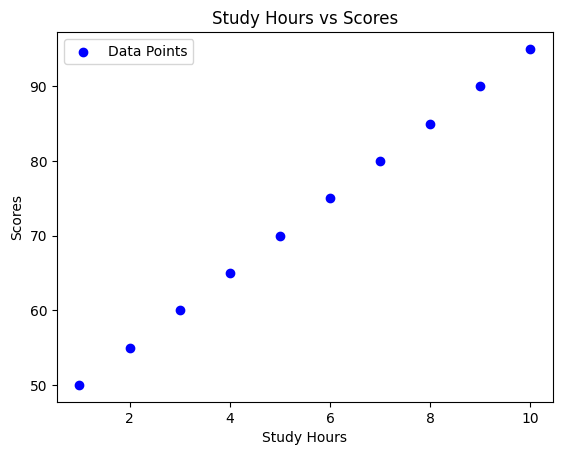

In [3]:
plt.scatter(X, Y, color="blue", label="Data Points")
plt.xlabel("Study Hours")
plt.ylabel("Scores")
plt.title("Study Hours vs Scores")
plt.legend()
plt.show()

In [4]:
model = LinearRegression()
model.fit(X, Y)

LinearRegression()

In [5]:
Y_pred = model.predict(X)

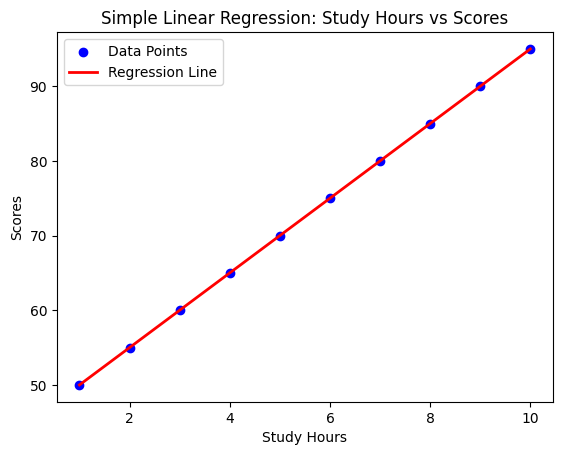

In [6]:
plt.scatter(X, Y, color="blue", label="Data Points")
plt.plot(X, Y_pred, color="red", linewidth=2, label="Regression Line")
plt.xlabel("Study Hours")
plt.ylabel("Scores")
plt.title("Simple Linear Regression: Study Hours vs Scores")
plt.legend()
plt.show()

In [10]:
mse = mean_squared_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)

# Print the results
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared: {r2}")

Mean Squared Error (MSE): 4.543838814073028e-29
R-squared: 1.0


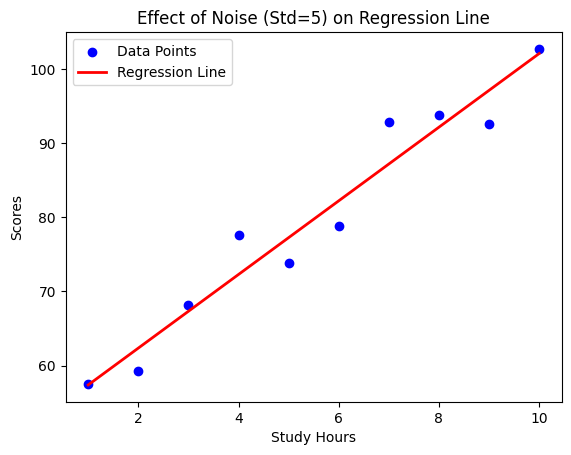

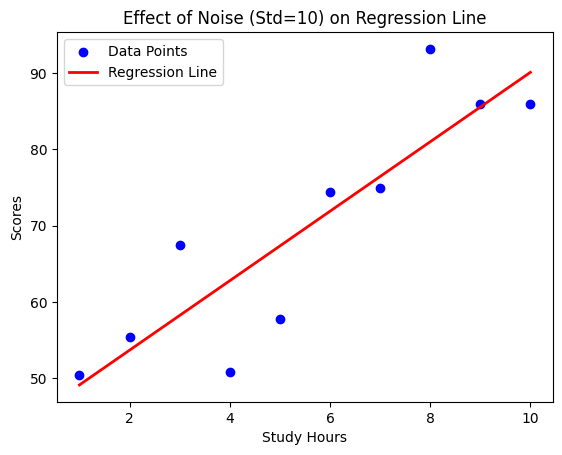

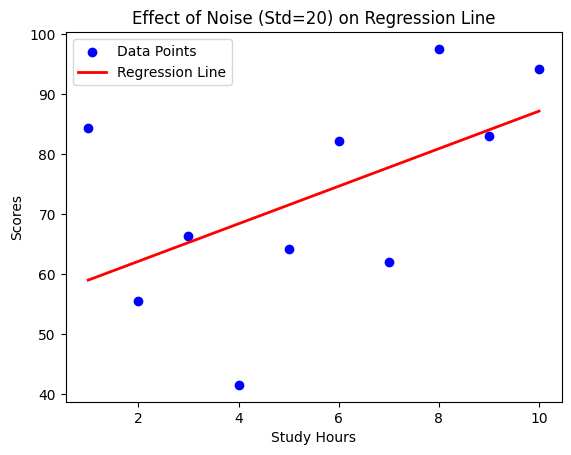

In [15]:
def plot_results(X, Y, Y_pred, title):
    plt.scatter(X, Y, color="blue", label="Data Points")
    plt.plot(X, Y_pred, color="red", linewidth=2, label="Regression Line")
    plt.xlabel("Study Hours")
    plt.ylabel("Scores")
    plt.title(title)
    plt.legend()
    plt.show()
np.random.seed(42)
X = np.array([[i] for i in range(1, 11)])
Y_true = 50 + 5 * X.flatten()

for noise_level in [5, 10, 20]:
    noise = np.random.normal(0, noise_level, size=len(X))
    Y_noisy = Y_true + noise
    model = LinearRegression()
    model.fit(X, Y_noisy)
    Y_pred_noisy = model.predict(X)
    plot_results(X, Y_noisy, Y_pred_noisy, f"Effect of Noise (Std={noise_level}) on Regression Line")

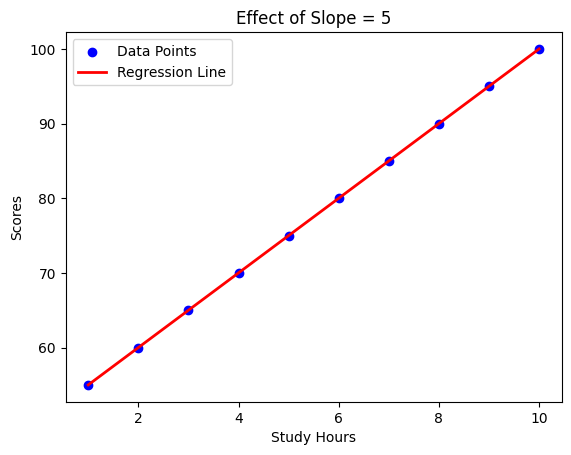

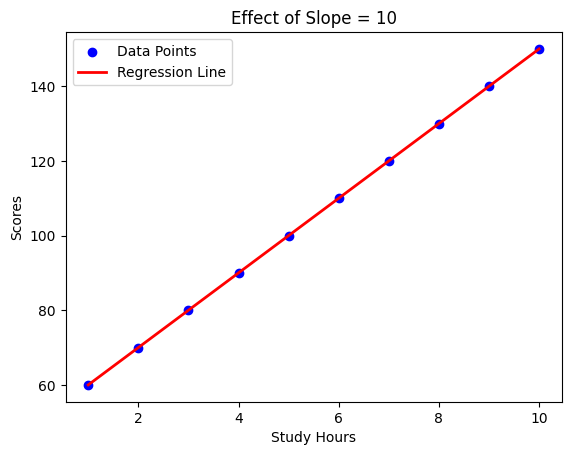

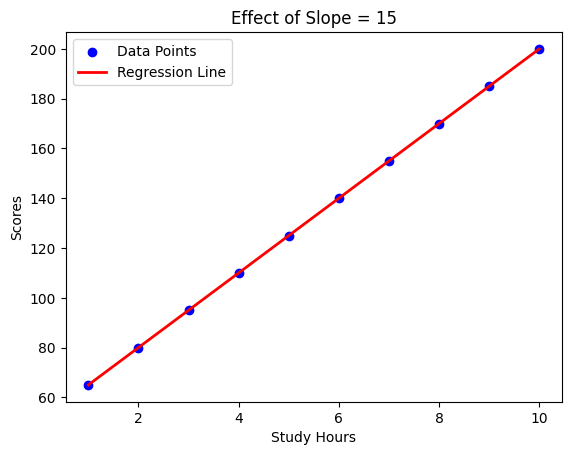

In [16]:
for slope in [5, 10, 15]:
    Y_changed_slope = 50 + slope * X.flatten()
    model.fit(X, Y_changed_slope)
    Y_pred_changed_slope = model.predict(X)
    plot_results(X, Y_changed_slope, Y_pred_changed_slope, f"Effect of Slope = {slope}")


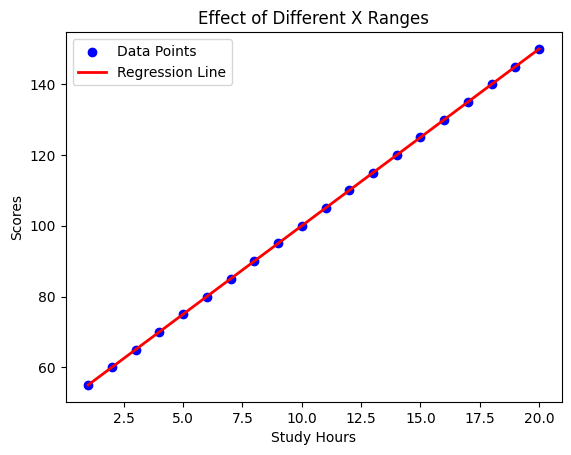

In [17]:
X_new = np.array([[i] for i in range(1, 21)])
Y_new = 50 + 5 * X_new.flatten()
model.fit(X_new, Y_new)
Y_pred_new = model.predict(X_new)
plot_results(X_new, Y_new, Y_pred_new, "Effect of Different X Ranges")


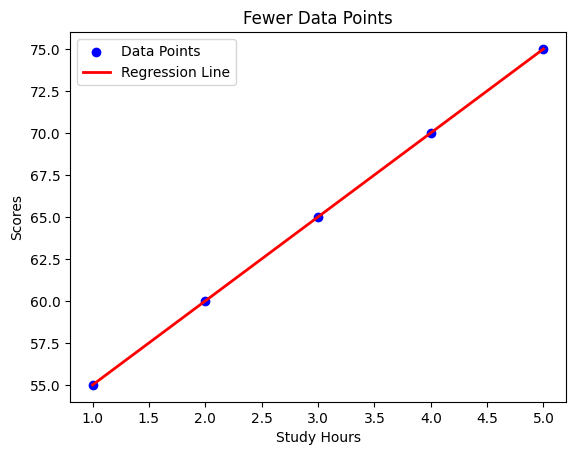

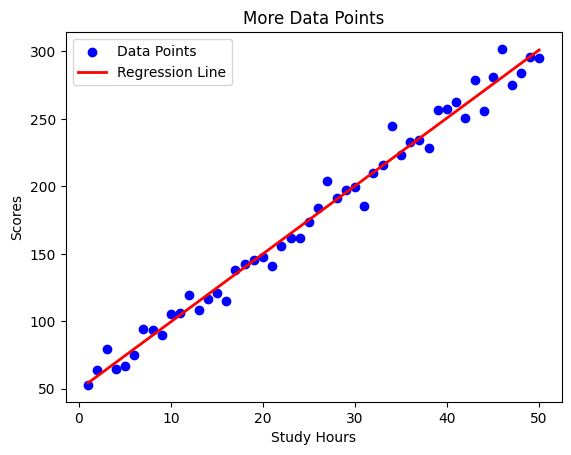

In [20]:
X_few = X[:5]
Y_few = Y_true[:5]
model.fit(X_few, Y_few)
Y_pred_few = model.predict(X_few)
plot_results(X_few, Y_few, Y_pred_few, "Fewer Data Points")

X_more = np.array([[i] for i in range(1, 51)])
Y_more = 50 + 5 * X_more.flatten() + np.random.normal(0, 10, size=len(X_more))
model.fit(X_more, Y_more)
Y_pred_more = model.predict(X_more)
plot_results(X_more, Y_more, Y_pred_more, "More Data Points")


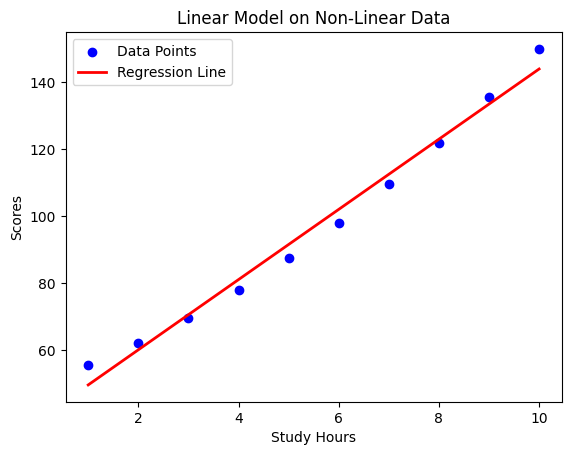

In [21]:
Y_quadratic = 50 + 5 * X.flatten() + 0.5 * X.flatten()**2
model.fit(X, Y_quadratic)
Y_pred_quadratic = model.predict(X)
plot_results(X, Y_quadratic, Y_pred_quadratic, "Linear Model on Non-Linear Data")


In [26]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [23]:
X_multi = np.column_stack((X, X**2))
model.fit(X_multi, Y)
Y_pred_multi = model.predict(X_multi)
print("R-squared with Multiple Variables:", r2_score(Y, Y_pred_multi))


R-squared with Multiple Variables: 1.0


In [24]:
print("R-squared using single feature:", r2_score(Y, Y_pred))
print("R-squared using multiple features:", r2_score(Y, Y_pred_multi))

R-squared using single feature: 1.0
R-squared using multiple features: 1.0


In [27]:
categories = np.array(["Fail" if score < 75 else "Pass" for score in Y]).reshape(-1, 1)
encoder = OneHotEncoder(drop='first')
categorical_encoded = encoder.fit_transform(categories).toarray()
X_with_cat = np.hstack((X, categorical_encoded))

model.fit(X_with_cat, Y)
Y_pred_cat = model.predict(X_with_cat)
print("R-squared with Categorical Variables:", r2_score(Y, Y_pred_cat))


R-squared with Categorical Variables: 1.0


In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_multi)
model.fit(X_scaled, Y)
Y_pred_scaled = model.predict(X_scaled)
print("R-squared with Normalized Data:", r2_score(Y, Y_pred_scaled))

R-squared with Normalized Data: 1.0
